# Aircraft Engine Predictive Maintenance

## Notebook 5: Advanced Machine Learning using XGBoost

### Objectives

- Train XGBoost Model
- Hyperparameter Tuning
- Cross Validation
- Save Best Model

In [5]:
import pandas as pd
import numpy as np

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor

import joblib

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [6]:
data = pd.read_csv("../dataset/processed_train.csv")

X = data.drop("RUL", axis=1)

y = data["RUL"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [8]:
from sklearn.model_selection import train_test_split

data = pd.read_csv("../dataset/processed_train.csv")

X = data.drop("RUL", axis=1)
y = data["RUL"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [9]:
print(data.head())

   engine_id    cycle  setting1  setting2  sensor_2  sensor_3  sensor_4  \
0        0.0  0.00000  0.459770  0.166667  0.183735  0.406802  0.309757   
1        0.0  0.00277  0.609195  0.250000  0.283133  0.453019  0.352633   
2        0.0  0.00554  0.252874  0.750000  0.343373  0.369523  0.370527   
3        0.0  0.00831  0.540230  0.500000  0.343373  0.256159  0.331195   
4        0.0  0.01108  0.390805  0.333333  0.349398  0.257467  0.404625   

   sensor_6  sensor_7  sensor_8  sensor_9  sensor_11  sensor_12  sensor_13  \
0       1.0  0.726248  0.242424  0.109755   0.369048   0.633262   0.205882   
1       1.0  0.628019  0.212121  0.100242   0.380952   0.765458   0.279412   
2       1.0  0.710145  0.272727  0.140043   0.250000   0.795309   0.220588   
3       1.0  0.740741  0.318182  0.124518   0.166667   0.889126   0.294118   
4       1.0  0.668277  0.242424  0.149960   0.255952   0.746269   0.235294   

   sensor_14  sensor_15  sensor_17  sensor_20  sensor_21    RUL  
0   0.199608  

In [10]:
data = pd.read_csv("../dataset/processed_train.csv")

X = data.drop("RUL", axis=1)

y = data["RUL"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [13]:
xgb = XGBRegressor(

    n_estimators=300,

    learning_rate=0.05,

    max_depth=6,

    subsample=0.8,

    colsample_bytree=0.8,

    random_state=42
)

xgb.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [14]:
prediction = xgb.predict(X_test)

In [15]:
mae = mean_absolute_error(y_test, prediction)

rmse = np.sqrt(mean_squared_error(y_test, prediction))

r2 = r2_score(y_test, prediction)

print("MAE :", mae)

print("RMSE :", rmse)

print("R2 :", r2)

MAE : 7.364313306941813
RMSE : 9.776723210219512
R2 : 0.9790788787588526


In [16]:
scores = cross_val_score(

    xgb,

    X,

    y,

    cv=5,

    scoring="r2"

)

print(scores)

print("Average R2 :", scores.mean())

[0.66107696 0.51231652 0.79340841 0.50166983 0.58922923]
Average R2 : 0.6115401892410758


In [17]:
parameters = {

    "max_depth":[4,6,8],

    "learning_rate":[0.01,0.05,0.1],

    "n_estimators":[100,200]

}

grid = GridSearchCV(

    XGBRegressor(),

    parameters,

    cv=3,

    scoring="r2",

    verbose=1

)

grid.fit(X_train,y_train)

grid.best_params_

Fitting 3 folds for each of 18 candidates, totalling 54 fits


{'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200}

In [18]:
best_model = grid.best_estimator_

prediction = best_model.predict(X_test)

print("Best R2 :",r2_score(y_test,prediction))

Best R2 : 0.9814235822720448


In [19]:
joblib.dump(

    best_model,

    "../models/xgboost_model.pkl"

)

print("Model Saved Successfully")

Model Saved Successfully


In [20]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":best_model.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

importance.head(20)

,Feature,Importance
1,cycle,0.365453
11,sensor_11,0.148349
6,sensor_4,0.117107
0,engine_id,0.080370
12,sensor_12,0.056406
10,sensor_9,0.047112
8,sensor_7,0.034893
15,sensor_15,0.021530
13,sensor_13,0.021087
14,sensor_14,0.020474


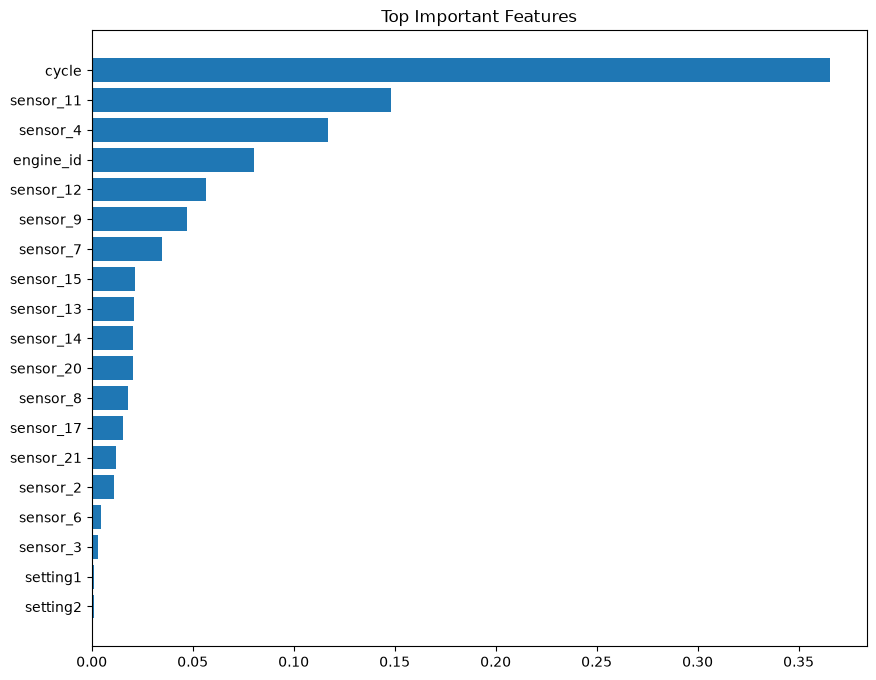

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

plt.barh(

    importance["Feature"][:20],

    importance["Importance"][:20]

)

plt.gca().invert_yaxis()

plt.title("Top Important Features")

plt.show()

In [22]:
sample = X_test.iloc[[10]]

prediction = best_model.predict(sample)

print("Predicted RUL :",prediction)

Predicted RUL : [100.35965]
